In [12]:
# Cell 1: Load Dataset and Identify Features

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/Iris.csv')
df = df.drop('Id', axis=1)
df['species'] = df['Species'].astype('category').cat.codes
df = df.drop('Species', axis=1)

print("Shape of dataset:", df.shape)
print("\nFeature names:", df.columns.tolist())
print("\nTarget variable: 'species'  (0=setosa, 1=versicolor, 2=virginica)")
print("\nFirst 5 rows:")
print(df.head())

Shape of dataset: (150, 5)

Feature names: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'species']

Target variable: 'species'  (0=setosa, 1=versicolor, 2=virginica)

First 5 rows:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  species
0            5.1           3.5            1.4           0.2        0
1            4.9           3.0            1.4           0.2        0
2            4.7           3.2            1.3           0.2        0
3            4.6           3.1            1.5           0.2        0
4            5.0           3.6            1.4           0.2        0


In [13]:
# Cell 2: Explore Dataset

print("\n1. Shape of dataset:")
print("   Rows:", df.shape[0], "| Columns:", df.shape[1])

print("\n2. Feature names:")
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
for f in features:
    print("  -", f)
print("  - species  ← target variable")

print("\n3. Dataset Info:")
print(df.info())

print("\n4. Statistical Summary:")
print(df.describe())

print("\n5. Missing values:")
print(df.isnull().sum())

print("\n6. Class distribution (target):")
print(df['species'].value_counts())


1. Shape of dataset:
   Rows: 150 | Columns: 5

2. Feature names:
  - SepalLengthCm
  - SepalWidthCm
  - PetalLengthCm
  - PetalWidthCm
  - species  ← target variable

3. Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   species        150 non-null    int8   
dtypes: float64(4), int8(1)
memory usage: 5.0 KB
None

4. Statistical Summary:
       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm     species
count     150.000000    150.000000     150.000000    150.000000  150.000000
mean        5.843333      3.054000       3.758667      1.198667    1.000000
std         0.828066      0.433594       1.764420      0.763161    0.819232
min         4.30000

In [14]:
# Cell 3: Check Need for Scaling

from sklearn.preprocessing import StandardScaler

features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
X = df[features]
y = df['species']

print("SCALING ANALYSIS")


print("\nFeature Ranges (Min → Max):")
for col in features:
    print(f"  {col:20s}: {X[col].min():.2f} → {X[col].max():.2f}  | std: {X[col].std():.2f}")

print("""
Reason for Scaling:
- SepalLengthCm range: 4.3 → 7.9
- PetalLengthCm range: 1.0 → 6.9
- PetalWidthCm range : 0.1 → 2.5
- Features have DIFFERENT ranges and std deviations
- PCA is sensitive to scale (larger range = more variance)
- So StandardScaler is REQUIRED before PCA
""")

# Apply Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("After Scaling — Mean and Std of each feature:")
scaled_df = pd.DataFrame(X_scaled, columns=features)
print(scaled_df.describe().loc[['mean', 'std']].round(4))

SCALING ANALYSIS

Feature Ranges (Min → Max):
  SepalLengthCm       : 4.30 → 7.90  | std: 0.83
  SepalWidthCm        : 2.00 → 4.40  | std: 0.43
  PetalLengthCm       : 1.00 → 6.90  | std: 1.76
  PetalWidthCm        : 0.10 → 2.50  | std: 0.76

Reason for Scaling:
- SepalLengthCm range: 4.3 → 7.9
- PetalLengthCm range: 1.0 → 6.9
- PetalWidthCm range : 0.1 → 2.5
- Features have DIFFERENT ranges and std deviations
- PCA is sensitive to scale (larger range = more variance)
- So StandardScaler is REQUIRED before PCA

After Scaling — Mean and Std of each feature:
      SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
mean        -0.0000       -0.0000         0.0000       -0.0000
std          1.0034        1.0034         1.0034        1.0034


In [15]:
# Cell 4: Apply PCA with 2 and 3 Components

from sklearn.decomposition import PCA

print("PCA ANALYSIS")

# ── PCA with 2 components ──
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

print("\nPCA with 2 Components:")
print(f"  Explained Variance Ratio : {pca2.explained_variance_ratio_}")
print(f"  Total Variance Explained : {sum(pca2.explained_variance_ratio_)*100:.2f}%")

# ── PCA with 3 components ──
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

print("\nPCA with 3 Components:")
print(f"  Explained Variance Ratio : {pca3.explained_variance_ratio_}")
print(f"  Total Variance Explained : {sum(pca3.explained_variance_ratio_)*100:.2f}%")

# ── Comparison ──
print("\n" + "=" * 45)
print("COMPARISON: 2 vs 3 Components")
print("=" * 45)
print(f"  2 Components → {sum(pca2.explained_variance_ratio_)*100:.2f}% variance retained")
print(f"  3 Components → {sum(pca3.explained_variance_ratio_)*100:.2f}% variance retained")
print(f"  Extra gain from 3rd component: {(pca3.explained_variance_ratio_[2])*100:.2f}%")



PCA ANALYSIS

PCA with 2 Components:
  Explained Variance Ratio : [0.72770452 0.23030523]
  Total Variance Explained : 95.80%

PCA with 3 Components:
  Explained Variance Ratio : [0.72770452 0.23030523 0.03683832]
  Total Variance Explained : 99.48%

COMPARISON: 2 vs 3 Components
  2 Components → 95.80% variance retained
  3 Components → 99.48% variance retained
  Extra gain from 3rd component: 3.68%


In [16]:
# Cell 5: Transform Data using PCA

print("=" * 45)
print("DATA TRANSFORMATION")
print("=" * 45)

# Shape before PCA
print(f"\nShape BEFORE PCA: {X_scaled.shape}")
print(f"  → 150 samples, 4 features")

# Transform using PCA 2 components (already done in Cell 4)
print(f"\nShape AFTER PCA (2 components): {X_pca2.shape}")
print(f"  → 150 samples, 2 principal components")

print(f"\nShape AFTER PCA (3 components): {X_pca3.shape}")
print(f"  → 150 samples, 3 principal components")

# Show transformed data
print("\nFirst 5 rows of Transformed Data (PCA 2):")
pca2_df = pd.DataFrame(X_pca2, columns=['PC1', 'PC2'])
pca2_df['species'] = y.values
print(pca2_df.head())

print("\nFirst 5 rows of Transformed Data (PCA 3):")
pca3_df = pd.DataFrame(X_pca3, columns=['PC1', 'PC2', 'PC3'])
pca3_df['species'] = y.values
print(pca3_df.head())

print("""
Dimension Reduction Summary:
  Original : 4 features  → PCA 2: 2 components (50% reduction)
  Original : 4 features  → PCA 3: 3 components (25% reduction)
""")

DATA TRANSFORMATION

Shape BEFORE PCA: (150, 4)
  → 150 samples, 4 features

Shape AFTER PCA (2 components): (150, 2)
  → 150 samples, 2 principal components

Shape AFTER PCA (3 components): (150, 3)
  → 150 samples, 3 principal components

First 5 rows of Transformed Data (PCA 2):
        PC1       PC2  species
0 -2.264542  0.505704        0
1 -2.086426 -0.655405        0
2 -2.367950 -0.318477        0
3 -2.304197 -0.575368        0
4 -2.388777  0.674767        0

First 5 rows of Transformed Data (PCA 3):
        PC1       PC2       PC3  species
0 -2.264542  0.505704  0.121943        0
1 -2.086426 -0.655405  0.227251        0
2 -2.367950 -0.318477 -0.051480        0
3 -2.304197 -0.575368 -0.098860        0
4 -2.388777  0.674767 -0.021428        0

Dimension Reduction Summary:
  Original : 4 features  → PCA 2: 2 components (50% reduction)
  Original : 4 features  → PCA 3: 3 components (25% reduction)



In [17]:
# Cell 6: Understand PCA Output

print("=" * 45)
print("UNDERSTANDING PCA OUTPUT")
print("=" * 45)

# PCA component loadings
print("\nPC1 Loadings (contribution of each feature):")
for feat, load in zip(features, pca2.components_[0]):
    print(f"  {feat:20s}: {load:+.4f}")

print("\nPC2 Loadings (contribution of each feature):")
for feat, load in zip(features, pca2.components_[1]):
    print(f"  {feat:20s}: {load:+.4f}")



UNDERSTANDING PCA OUTPUT

PC1 Loadings (contribution of each feature):
  SepalLengthCm       : +0.5224
  SepalWidthCm        : -0.2634
  PetalLengthCm       : +0.5813
  PetalWidthCm        : +0.5656

PC2 Loadings (contribution of each feature):
  SepalLengthCm       : +0.3723
  SepalWidthCm        : +0.9256
  PetalLengthCm       : +0.0211
  PetalWidthCm        : +0.0654


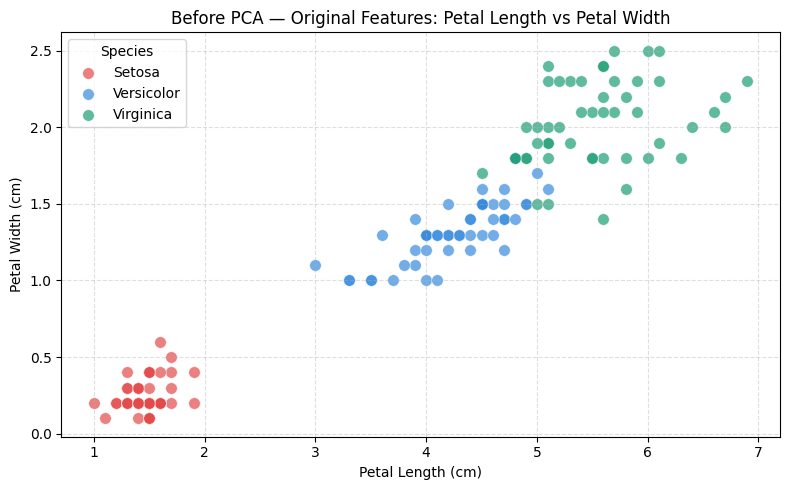

In [18]:
# Cell 7: Visualization Before PCA (Original Features)

species_names = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
colors = {0: '#E24B4A', 1: '#378ADD', 2: '#1D9E75'}

plt.figure(figsize=(8, 5))

for species_id in [0, 1, 2]:
    mask = y == species_id
    plt.scatter(
        X['PetalLengthCm'][mask],
        X['PetalWidthCm'][mask],
        label=species_names[species_id],
        color=colors[species_id],
        alpha=0.7,
        edgecolors='white',
        linewidths=0.5,
        s=70
    )

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Before PCA — Original Features: Petal Length vs Petal Width')
plt.legend(title='Species')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



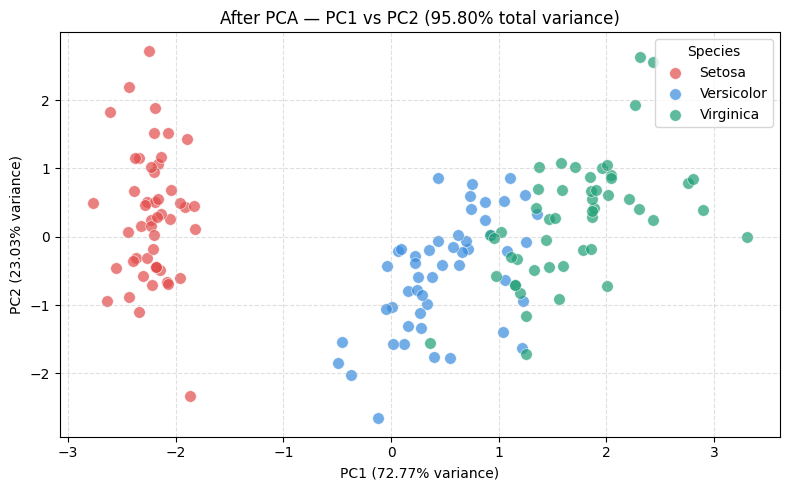

In [19]:
# Cell 8: Visualization After PCA (PC1 vs PC2)

plt.figure(figsize=(8, 5))

for species_id in [0, 1, 2]:
    mask = y == species_id
    plt.scatter(
        X_pca2[mask, 0],
        X_pca2[mask, 1],
        label=species_names[species_id],
        color=colors[species_id],
        alpha=0.7,
        edgecolors='white',
        linewidths=0.5,
        s=70
    )

plt.xlabel(f'PC1 (72.77% variance)')
plt.ylabel(f'PC2 (23.03% variance)')
plt.title('After PCA — PC1 vs PC2 (95.80% total variance)')
plt.legend(title='Species')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

